In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.models.intermediate import intermediate_model
from src.algos.EXP3 import simple_exp3
from src.algos.UCB1 import simple_ucb1

K = 2
T = 1000
n_runs = 10

alpha = [0.9, 0.1]
sigma = [0.1] * K

betas = np.linspace(0, 1, 20)  # range to sweep

⠏: [XXXXXXXXX-] (9 / 10) | ⠏: [XXXXXXXXX-] (999 / 1000)

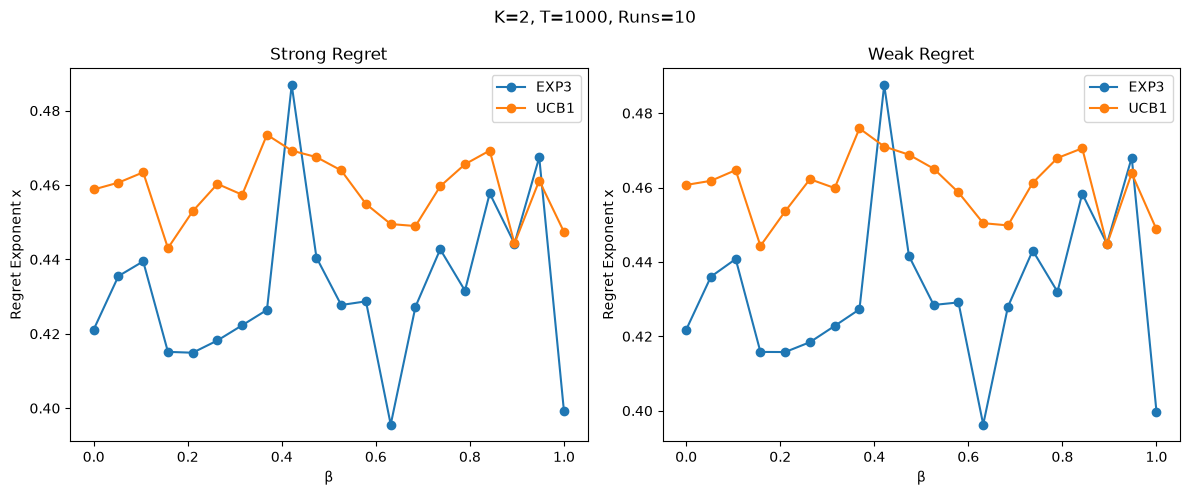

In [3]:
exp3_scores = []
exp3_wk_scores = []
ucb1_scores = []
ucb1_wk_scores = []

for beta_val in betas:
    beta = [beta_val] * K
    
    model = intermediate_model(K, T)
    model.gen(alpha, beta, sigma)
    
    # EXP3
    exp3 = simple_exp3(model)
    reg, wk_reg = exp3.eval(n_runs=n_runs, graph=False)
    exp3_scores.append(reg)
    exp3_wk_scores.append(wk_reg)
    
    # UCB1
    ucb1 = simple_ucb1(model)
    reg, wk_reg = ucb1.eval(n_runs=n_runs, graph=False)
    ucb1_scores.append(reg)
    ucb1_wk_scores.append(wk_reg)

# plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(betas, exp3_scores, label='EXP3', marker='o')
plt.plot(betas, ucb1_scores, label='UCB1', marker='o')
plt.xlabel('β')
plt.ylabel('Regret Exponent x')
plt.title('Strong Regret')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(betas, exp3_wk_scores, label='EXP3', marker='o')
plt.plot(betas, ucb1_wk_scores, label='UCB1', marker='o')
plt.xlabel('β')
plt.ylabel('Regret Exponent x')
plt.title('Weak Regret')
plt.legend()

plt.suptitle(f'K={K}, T={T}, Runs={n_runs}')
plt.tight_layout()
plt.show()